In [2]:
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

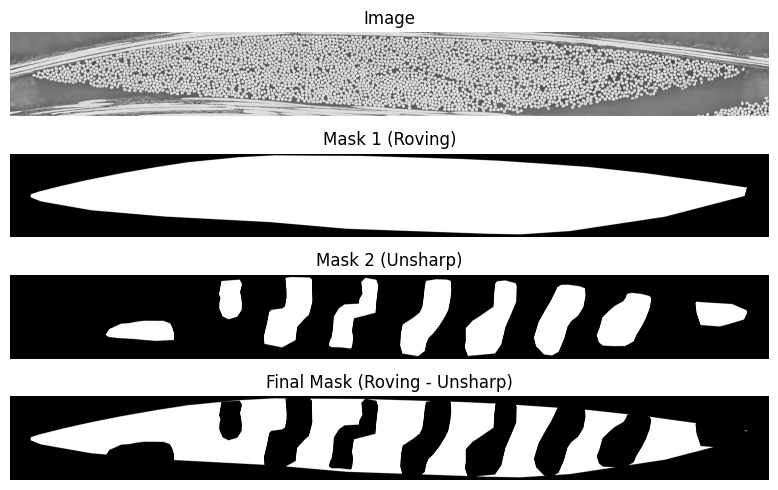

In [5]:
file_path  = Path("../../data/promotion/245_004.adj.tif")
mask1_path = Path("../../data/promotion/245_004.adj.mask.tif")
mask2_path = Path("../../data/promotion/245_004.adj.mask.unsharp.tif")

# --- Load image ---
image_np = np.array(Image.open(file_path).convert("L"))

# --- Load masks ---
mask1 = np.array(Image.open(mask1_path).convert("L"))
mask2 = np.array(Image.open(mask2_path).convert("L"))

# --- Convert to binary ---
mask1_bin = mask1 > 0
mask2_bin = mask2 > 0


assert mask1.shape == mask2.shape, "Mask shapes do not match!"
# --- Subtract mask2 from mask1 ---
final_mask = mask1_bin & (~mask2_bin)

# Convert to uint8 for saving / display
final_mask_u8 = (final_mask * 255).astype(np.uint8)

# --- Display ---
fig, ax = plt.subplots(4,1, figsize=(18,5))

ax[0].imshow(image_np, cmap="gray")
ax[0].set_title("Image")
ax[0].axis("off")

ax[1].imshow(mask1_bin, cmap="gray")
ax[1].set_title("Mask 1 (Roving)")
ax[1].axis("off")

ax[2].imshow(mask2_bin, cmap="gray")
ax[2].set_title("Mask 2 (Unsharp)")
ax[2].axis("off")

ax[3].imshow(final_mask_u8, cmap="gray")
ax[3].set_title("Final Mask (Roving - Unsharp)")
ax[3].axis("off")

plt.tight_layout()
plt.show()

In [10]:
def extract_image_patches_mask_aware(
    image_np: np.ndarray,
    mask: np.ndarray,
    patch_size: int = 512,
    stride: int = 256,
    min_mask_fraction: float = 0.9,
):
    """
    Extract patches from image_np using a binary mask as a filter.

    Keeps only patches where mean(mask_patch) >= min_mask_fraction.

    Parameters
    ----------
    image_np : np.ndarray
        Image array (H,W) or (H,W,C).

    mask : np.ndarray
        Binary mask (H,W) or numeric mask where >0 means True.

    patch_size : int
        Patch size (square).

    stride : int
        Sliding window stride.

    min_mask_fraction : float
        Minimum fraction of True pixels inside the mask patch to keep.

    Returns
    -------
    img_patches : np.ndarray
        (N, patch_size, patch_size) or (N, patch_size, patch_size, C)

    mask_patches : np.ndarray
        (N, patch_size, patch_size) boolean

    coords : list[tuple[int,int]]
        Top-left (y, x) coordinates for each patch.
    """
    if mask.ndim != 2:
        raise ValueError(f"mask must be (H,W), got {mask.shape}")

    H, W = mask.shape
    if image_np.shape[0] != H or image_np.shape[1] != W:
        raise ValueError(f"image_np shape {image_np.shape[:2]} does not match mask shape {mask.shape}")

    mask_bin = mask.astype(bool)  # treat >0 as True if mask is uint8/0-255

    img_patches = []
    mask_patches = []
    coords = []

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            m = mask_bin[y:y+patch_size, x:x+patch_size]
            frac = m.mean()  # fraction of True

            if frac < min_mask_fraction:
                continue

            img_patches.append(image_np[y:y+patch_size, x:x+patch_size].copy())
            mask_patches.append(m.copy())
            coords.append((y, x))

    if len(img_patches) == 0:
        # return empty arrays with correct shapes
        if image_np.ndim == 2:
            img_shape = (0, patch_size, patch_size)
        else:
            img_shape = (0, patch_size, patch_size, image_np.shape[2])
        return np.empty(img_shape, dtype=image_np.dtype), np.empty((0, patch_size, patch_size), dtype=bool), []

    return np.stack(img_patches, axis=0), np.stack(mask_patches, axis=0), coords

In [25]:
img_patches, m_patches, coords = extract_image_patches_mask_aware(
    image_np=image_np,
    mask=final_mask,          # bool or 0/255
    patch_size=512,
    stride=64,
    min_mask_fraction=0.9
)

img_patches = img_patches[:20]

print("Number of patches:", len(img_patches))

file_out_base = file_path.parent / f"{file_path.stem}.patches.deghost"

# ---- Shuffle ----
N = len(img_patches)
indices = np.random.permutation(N)

split_idx = int(0.8 * N)

train_idx = indices[:split_idx]
val_idx   = indices[split_idx:]

train_patches = img_patches[train_idx]
val_patches   = img_patches[val_idx]

# ---- Save ----
train_path = file_out_base.with_suffix(".small.train.npy")
val_path   = file_out_base.with_suffix(".small.val.npy")

np.save(train_path, train_patches)
np.save(val_path, val_patches)

print("Train:", train_patches.shape, "->", train_path)
print("Val  :", val_patches.shape,   "->", val_path)

for patch in img_patches[20:25]:
    plt.imshow(patch,cmap="gray",vmin = 0 ,vmax =255)
    plt.show()

Number of patches: 20
Train: (16, 512, 512) -> ../../data/promotion/245_004.adj.patches.small.train.npy
Val  : (4, 512, 512) -> ../../data/promotion/245_004.adj.patches.small.val.npy


In [22]:
out_path = file_path.parent / "patches"

out_path.mkdir(exist_ok=True)

for idx, patch in enumerate(img_patches):

    
    out_file = out_path / f"{file_path.stem}_{idx:03d}.tif"



    Image.fromarray(patch.astype(np.uint8)).convert("L").save(out_file)